# Tema 12 — Clasificación de imágenes con CNN y Transfer Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecamposv/nlp-vision/blob/main/semana-06/Tema-12/Tema_12.ipynb)

Puedes ejecutar este notebook localmente (VS Code / Jupyter) o en **Google Colab** dando clic en el badge de arriba.

En este notebook entrenamos una **red neuronal convolucional (CNN)** desde cero sobre el dataset **CIFAR-10**, y luego comparamos su desempeño con **transfer learning** y **fine-tuning** usando el modelo preentrenado **EfficientNetB0**.

> 💡 Se recomienda ejecutar en Colab con **GPU** activada (Entorno de ejecución → Cambiar tipo de entorno → GPU) para acelerar el entrenamiento.

**CNN básica entrenada desde cero**

### ¿Qué hace este código?

Entrena una **CNN desde cero** para clasificar las 10 categorías de **CIFAR-10**:

1. **Carga del dataset** CIFAR-10 (60 000 imágenes de 32×32 px) con `tf.keras.datasets`.
2. **Normalización**: los píxeles se escalan de 0–255 a un rango 0–1 para ayudar al entrenamiento.
3. **Arquitectura**: tres bloques **`Conv2D` + `MaxPooling2D`** que extraen características, seguidos de capas densas. El **`Dropout(0.3)`** reduce el sobreajuste y la capa final **`softmax`** entrega la probabilidad de cada una de las 10 clases.
4. **Compilación** con el optimizador **Adam** y la pérdida `sparse_categorical_crossentropy` (etiquetas como enteros).
5. **Entrenamiento** durante 15 épocas reservando un 20 % para validación, y **evaluación** final sobre el conjunto de prueba.

> ⏱️ Este entrenamiento puede tardar varios minutos; con GPU es mucho más rápido.

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Cargar dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalizar imágenes
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Nombres de las clases
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'venado',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# 4. Definir CNN básica
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 5. Compilar modelo
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 6. Entrenar
history_cnn = cnn_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# 7. Evaluar
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print("Accuracy CNN básica:", test_acc)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.3924 - loss: 1.6556 - val_accuracy: 0.5131 - val_loss: 1.3618
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5355 - loss: 1.3013 - val_accuracy: 0.5965 - val_loss: 1.1560
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5913 - loss: 1.1587 - val_accuracy: 0.6269 - val_loss: 1.0730
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6193 - loss: 1.0869 - val_accuracy: 0.6481 - val_loss: 1.0139
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6393 - loss: 1.0490 - val_accuracy: 0.6274 - val_loss: 1.0695
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6535 - loss: 1.0163 - val_accuracy: 0.6709 - val_loss: 0.9426
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6643 - loss: 0.9787 - val_accuracy: 0.6818 - val_loss: 0.9343
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6693 - loss: 0.9691 - 

Transfer learning con EfficientNetB0

### ¿Qué hace este código?

Aplica **transfer learning** reutilizando un modelo ya entrenado en millones de imágenes (**ImageNet**):

1. **Pipeline `tf.data` optimizado**: en vez de redimensionar las imágenes de golpe a 224×224 (lo que consume mucha memoria y provoca un error **OOM**), se crean datasets que **redimensionan por lotes**. Además:
   - Se usa un **subconjunto** (`N_TRAIN`, `N_TEST`) porque con transfer learning bastan pocas imágenes para buena precisión → entrena mucho más rápido.
   - Se **cachea en disco temporal** (`/tmp`, válido en Colab y en local) para que el resize se calcule **una sola vez** y no en cada época.
   - Se usa `BATCH = 64` para aprovechar mejor la GPU.
2. Carga el modelo base **EfficientNetB0** con `include_top=False` (sin la capa de clasificación original) y pesos de **ImageNet**.
3. **Congela** el modelo base (`trainable = False`): se usa solo como **extractor de características**, sin reentrenar sus pesos.
4. Añade una cabeza nueva: `GlobalAveragePooling2D` + `Dropout` + una capa `Dense` **softmax** con 10 salidas.
5. **Compila, entrena** (solo la cabeza) con **`EarlyStopping`** (corta si la validación deja de mejorar) y **evalúa** con `test_ds`.

> ⚡ La **primera época** es más lenta porque construye la caché; las siguientes son mucho más rápidas.
> 💡 Para usar **todas** las imágenes, sube `N_TRAIN`/`N_TEST` (más precisión, más tiempo). Si te falta memoria, baja `BATCH`.

In [14]:
# 1. Pipeline de datos: redimensiona a 224x224 POR LOTES (evita el error OOM)
# En lugar de redimensionar las 50 000 imágenes de golpe (~30 GB), usamos
# tf.data para hacerlo sobre la marcha, lote por lote.
import os
import tempfile

IMG_SIZE = (224, 224)
BATCH = 64                 # batch más grande = mejor uso de la GPU
AUTOTUNE = tf.data.AUTOTUNE

# Subconjunto: con transfer learning bastan pocas imágenes para buena precisión.
# Reduce el tiempo de entrenamiento y el tamaño de la caché (funciona bien en Colab).
N_TRAIN = 15000   # de 50 000 -> menos tiempo, menos disco
N_TEST = 3000     # de 10 000

# Caché en disco temporal (/tmp en Colab y en local): el resize 32->224
# se calcula UNA sola vez y se reutiliza en cada época.
CACHE_DIR = os.path.join(tempfile.gettempdir(), "tf_cache_tema12")
os.makedirs(CACHE_DIR, exist_ok=True)

# Tomamos el subconjunto
x_sub, y_sub = x_train[:N_TRAIN], y_train[:N_TRAIN]
x_test_sub, y_test_sub = x_test[:N_TEST], y_test[:N_TEST]

# Separación manual train/validación (20%), ya que tf.data no usa validation_split
val_count = int(len(x_sub) * 0.2)
x_tr, y_tr = x_sub[:-val_count], y_sub[:-val_count]
x_val, y_val = x_sub[-val_count:], y_sub[-val_count:]

def make_ds(x, y, cache_name, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    # EfficientNet trae su propia normalización interna y espera píxeles en [0, 255];
    # como x_train ya está en [0, 1], lo reescalamos de vuelta multiplicando por 255.
    ds = ds.map(lambda img, lbl: (tf.image.resize(img, IMG_SIZE) * 255.0, lbl),
                num_parallel_calls=AUTOTUNE)
    # cache a disco temporal: el resize se calcula una sola vez y se reutiliza.
    ds = ds.cache(os.path.join(CACHE_DIR, cache_name))
    if training:
        ds = ds.shuffle(2000)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(x_tr, y_tr, "train", training=True)
val_ds = make_ds(x_val, y_val, "val")
test_ds = make_ds(x_test_sub, y_test_sub, "test")

# 2. Modelo base preentrenado
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# 3. Congelar extractor de características
base_model.trainable = False

# 4. Construir modelo final
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 5. Compilar
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# EarlyStopping: detiene el entrenamiento si la validación deja de mejorar
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)

# 6. Entrenar
history_tl = tl_model.fit(
    train_ds,
    epochs=8,
    validation_data=val_ds,
    callbacks=[early_stop]
)

# 7. Evaluar
test_loss_tl, test_acc_tl = tl_model.evaluate(test_ds)
print("Accuracy Transfer Learning:", test_acc_tl)


Epoch 1/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 90s 436ms/step - accuracy: 0.7337 - loss: 0.8753 - val_accuracy: 0.8537 - val_loss: 0.4637
Epoch 2/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 80s 420ms/step - accuracy: 0.8486 - loss: 0.4754 - val_accuracy: 0.8677 - val_loss: 0.3866
Epoch 3/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 395ms/step - accuracy: 0.8640 - loss: 0.4143 - val_accuracy: 0.8753 - val_loss: 0.3589
Epoch 4/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 405ms/step - accuracy: 0.8752 - loss: 0.3782 - val_accuracy: 0.8810 - val_loss: 0.3407
Epoch 5/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.8786 - loss: 0.3575 - val_accuracy: 0.8840 - val_loss: 0.3332
Epoch 6/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.8851 - loss: 0.3479 - val_accuracy: 0.8910 - val_loss: 0.3195
Epoch 7/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.8878 - loss: 0.3298 - val_accuracy: 0.8883 - val_loss: 0.3133
Epoch 8/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 86s 454ms/step - accuracy: 0.8904 - loss: 0.3196 - val_ac

**Fine-tuning parcial**

### ¿Qué hace este código?

Mejora el modelo con **fine-tuning**: ajusta las últimas capas del modelo preentrenado a nuestro problema:

1. **Descongela** el modelo base (`trainable = True`) pero vuelve a congelar todas las capas **excepto las últimas 20**, que son las que se reentrenarán.
2. **Recompila** con un **learning rate muy pequeño** (`1e-5`) para no destruir lo que el modelo ya aprendió.
3. **Reentrena** unas pocas épocas y vuelve a **evaluar**.

> 💡 El fine-tuning suele dar el último empujón de precisión, pero usar un learning rate alto aquí puede empeorar el modelo.

In [15]:
# Descongelar las últimas capas del modelo base
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompilar con learning rate pequeño
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Reentrenar (reutiliza los datasets cacheados; EarlyStopping corta si no mejora)
history_ft = tl_model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=[early_stop]
)

# Evaluación final
test_loss_ft, test_acc_ft = tl_model.evaluate(test_ds)
print("Accuracy Fine-Tuning:", test_acc_ft)


Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1903s 5s/step - accuracy: 0.8459 - loss: 0.4840 - val_accuracy: 0.8890 - val_loss: 0.3414
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 417ms/step - accuracy: 0.8679 - loss: 0.4104 - val_accuracy: 0.8880 - val_loss: 0.3380
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 269ms/step - accuracy: 0.8690 - loss: 0.3734
Accuracy Fine-Tuning: 0.8690000176429749


**Curvas de entrenamiento**

### ¿Qué hace este código?

Define una función para **graficar las curvas de entrenamiento** y la usa para comparar modelos:

1. `plot_history` recibe el historial devuelto por `model.fit` y dibuja dos gráficas: **accuracy** y **loss**.
2. En cada gráfica se comparan las curvas de **entrenamiento** vs **validación** a lo largo de las épocas.
3. Se grafican los resultados de la **CNN básica** y del **Transfer Learning**.

> 🔍 Si la curva de entrenamiento sube pero la de validación se estanca o baja, es señal de **sobreajuste**.

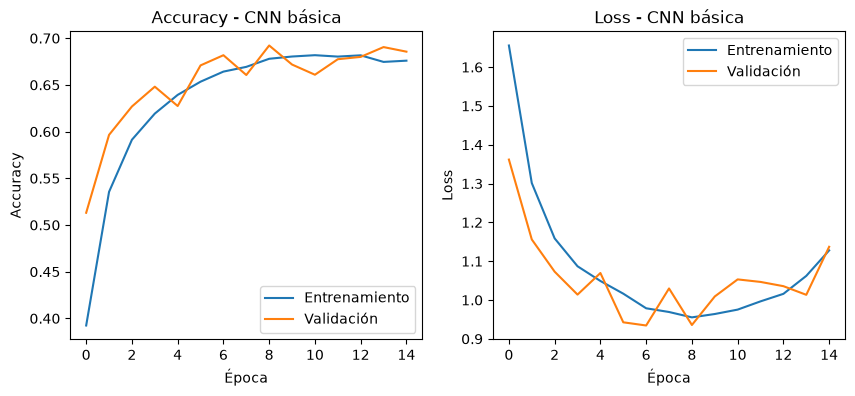

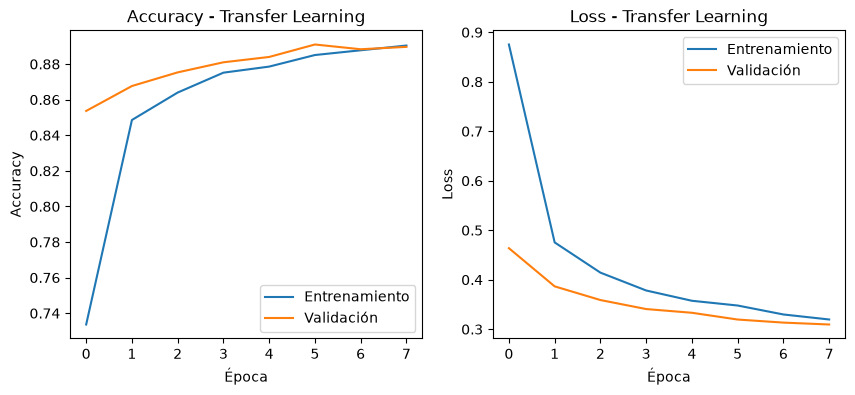

In [16]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Loss - {title}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history_cnn, "CNN básica")
plot_history(history_tl, "Transfer Learning")

**Matriz de confusión y reporte de clasificación**

### ¿Qué hace este código?

Evalúa en detalle el modelo final con una **matriz de confusión** y un **reporte de clasificación**:

1. Genera predicciones sobre el conjunto de prueba y convierte las probabilidades en clases con `np.argmax`.
2. **Matriz de confusión** (`confusion_matrix`): muestra, para cada clase real, cuántas imágenes se predijeron en cada categoría. Se visualiza como un mapa de calor con `seaborn`.
3. **`classification_report`**: imprime **precisión, recall y F1-score** por clase, útil para detectar qué categorías confunde más el modelo.

> 🔍 Los valores fuera de la diagonal de la matriz indican los errores (por ejemplo, confundir *gato* con *perro*).

47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 368ms/step


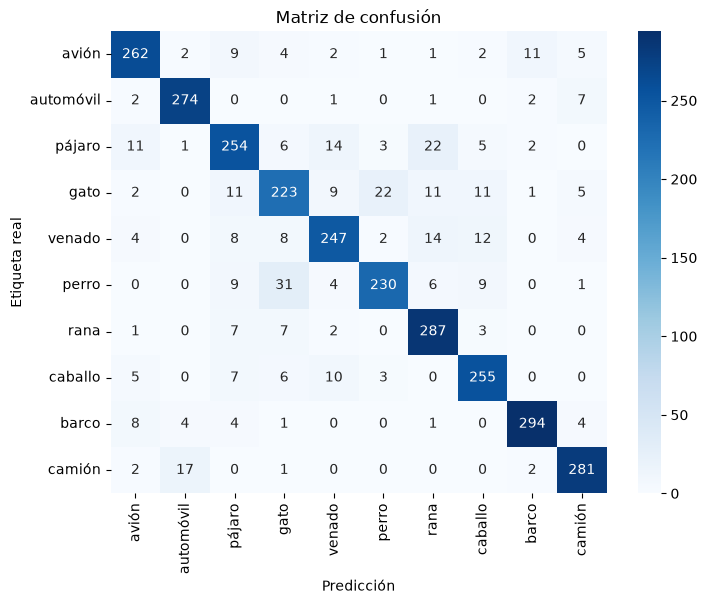

              precision    recall  f1-score   support

       avión       0.88      0.88      0.88       299
   automóvil       0.92      0.95      0.94       287
      pájaro       0.82      0.80      0.81       318
        gato       0.78      0.76      0.77       295
      venado       0.85      0.83      0.84       299
       perro       0.88      0.79      0.83       290
        rana       0.84      0.93      0.88       307
     caballo       0.86      0.89      0.87       286
       barco       0.94      0.93      0.94       316
      camión       0.92      0.93      0.92       303

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



In [17]:
# Predicciones con el modelo final (usa el dataset de prueba por lotes)
y_pred = tl_model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# Usamos el mismo subconjunto de prueba que test_ds
y_true = y_test_sub.flatten()

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión")
plt.show()

# Reporte de clasificación
print(classification_report(y_true, y_pred_classes, target_names=class_names))
